# Contrastive Decoding (Black Image) Analysis

Compares model behavior on closed questions when the real image is replaced by a plain black image.
Key questions:
- Does the emotion prompt bias Yes/No even without visual input?
- How does black-image accuracy compare to real-image accuracy?
- Which emotion conditions are most / least affected by removing vision?

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Configuration ──────────────────────────────────────────────
MODEL        = "medgemma"   # "medgemma" or "lingshu"
DATASET      = "vqarad"     # "slake" or "vqarad"
BLACK_DIR    = Path("/workspace/EmoMedicalVLM/output/phase_2/contrastive_decoding")

# Real-image results for comparison (phase_2 single-turn closed files)
REAL_DIR_MAP = {
    "medgemma": Path("/workspace/EmoMedicalVLM/output/phase_2/MedGemma"),
    "lingshu":  Path("/workspace/EmoMedicalVLM/output/phase_2/Lingshu"),
}
DATASET_KEY_MAP = {
    "slake":  "SLAKE",
    "vqarad": "vqa-rad",
}
REAL_DIR  = REAL_DIR_MAP[MODEL]
REAL_KEY  = DATASET_KEY_MAP[DATASET]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
label_map = {
    "default":                           "default",
    "direct_clinician_neutral":          "clin_neutral_dir",
    "direct_clinician_fear_anxiety":     "clin_fear_dir",
    "direct_clinician_anger_frustration":"clin_anger_dir",
    "direct_clinician_sadness_distress": "clin_sad_dir",
    "direct_patient_neutral":            "pat_neutral_dir",
    "direct_patient_fear_anxiety":       "pat_fear_dir",
    "direct_patient_anger_frustration":  "pat_anger_dir",
    "direct_patient_sadness_distress":   "pat_sad_dir",
    "indirect_clinician_neutral":        "clin_neutral_Indir",
    "indirect_clinician_fear_anxiety":   "clin_fear_Indir",
    "indirect_clinician_anger_frustration": "clin_anger_Indir",
    "indirect_clinician_sadness_distress":  "clin_sad_Indir",
    "indirect_patient_neutral":          "pat_neutral_Indir",
    "indirect_patient_fear_anxiety":     "pat_fear_Indir",
    "indirect_patient_anger_frustration":"pat_anger_Indir",
    "indirect_patient_sadness_distress": "pat_sad_Indir",
}

row_order = list(label_map.values())


def parse_answer(text):
    if text is None:
        return "Undecided"
    text = str(text).strip()
    t = text.lower()
    if text.startswith("Yes"): return "Yes"
    if text.startswith("No"):  return "No"
    if "yes" in t and "no" not in t: return "Yes"
    if "no" in t and "yes" not in t: return "No"
    return "Undecided"


def yes_rate(yes, no):
    total = yes + no
    return yes / total if total else np.nan


def build_similarity_matrix(answer_df, columns):
    arr = answer_df[columns].values
    m = arr.shape[0]
    if m == 0:
        return pd.DataFrame(np.zeros((len(columns), len(columns))), index=columns, columns=columns)
    sim = (arr[:, :, None] == arr[:, None, :]).mean(axis=0)
    return pd.DataFrame(sim, index=columns, columns=columns)


def plot_heatmap(mat, title, figsize=(11, 9), fontsize=8):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat.astype(float), aspect="auto", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, label="Similarity")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=fontsize)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 1. Load black-image results

In [3]:
black_records = []
answer_cols = {}   # emotion_key -> list of predicted answers (for similarity matrix)

for emotion_key, short in label_map.items():
    fname = f"{MODEL}_black_{DATASET}_{emotion_key}.jsonl"
    fpath = BLACK_DIR / fname
    if not fpath.exists():
        print(f"  MISSING: {fname}")
        continue

    preds, gts, yes_probs, no_probs = [], [], [], []
    with open(fpath, encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            preds.append(parse_answer(item.get("model_answer")))
            gts.append(parse_answer(item.get("answer")))
            yes_probs.append(item.get("yes_prob", np.nan))
            no_probs.append(item.get("no_prob", np.nan))

    yes = sum(p == "Yes" for p in preds)
    no  = sum(p == "No"  for p in preds)
    undecided = len(preds) - yes - no
    tp = sum(p == "Yes" and g == "Yes" for p, g in zip(preds, gts))
    tn = sum(p == "No"  and g == "No"  for p, g in zip(preds, gts))
    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else np.nan

    black_records.append({
        "emotion": emotion_key,
        "prompt": short,
        "yes": yes, "no": no, "undecided": undecided,
        "acc": round(acc, 4),
        "yes_rate": round(yes_rate(yes, no), 4),
        "mean_yes_prob": round(float(np.nanmean(yes_probs)), 4),
        "mean_no_prob":  round(float(np.nanmean(no_probs)),  4),
        "mean_max_prob": round(float(np.nanmean(np.maximum(yes_probs, no_probs))), 4),
        "total": len(preds),
    })
    answer_cols[short] = preds

black_df = pd.DataFrame(black_records)
# enforce display order
available = [p for p in row_order if p in set(black_df["prompt"])]
black_df["prompt"] = pd.Categorical(black_df["prompt"], categories=available, ordered=True)
black_df = black_df.sort_values("prompt").reset_index(drop=True)
black_df["prompt"] = black_df["prompt"].astype(str)

print(f"Loaded {len(black_df)} emotion conditions | samples per file: {black_df['total'].iloc[0]}")
black_df[["prompt", "yes", "no", "undecided", "acc", "yes_rate", "mean_yes_prob", "mean_max_prob"]]

Loaded 17 emotion conditions | samples per file: 251


,prompt,yes,no,undecided,acc,yes_rate,mean_yes_prob,mean_max_prob
0,default,20,230,1,0.5600,0.0800,0.0989,0.9514
1,clin_neutral_dir,6,244,1,0.5560,0.0240,0.0334,0.9831
2,clin_fear_dir,5,245,1,0.5520,0.0200,0.0233,0.9901
3,clin_anger_dir,3,247,1,0.5440,0.0120,0.0138,0.9937
4,clin_sad_dir,3,247,1,0.5440,0.0120,0.0199,0.9898
5,pat_neutral_dir,6,243,2,0.5542,0.0241,0.0280,0.9858
6,pat_fear_dir,4,245,2,0.5462,0.0161,0.0315,0.9815
7,pat_anger_dir,2,249,0,0.5378,0.0080,0.0108,0.9942
8,pat_sad_dir,4,245,2,0.5462,0.0161,0.0216,0.9879
9,clin_neutral_Indir,14,237,0,0.5538,0.0558,0.0593,0.9653


## 2. Accuracy & Yes-rate by emotion condition

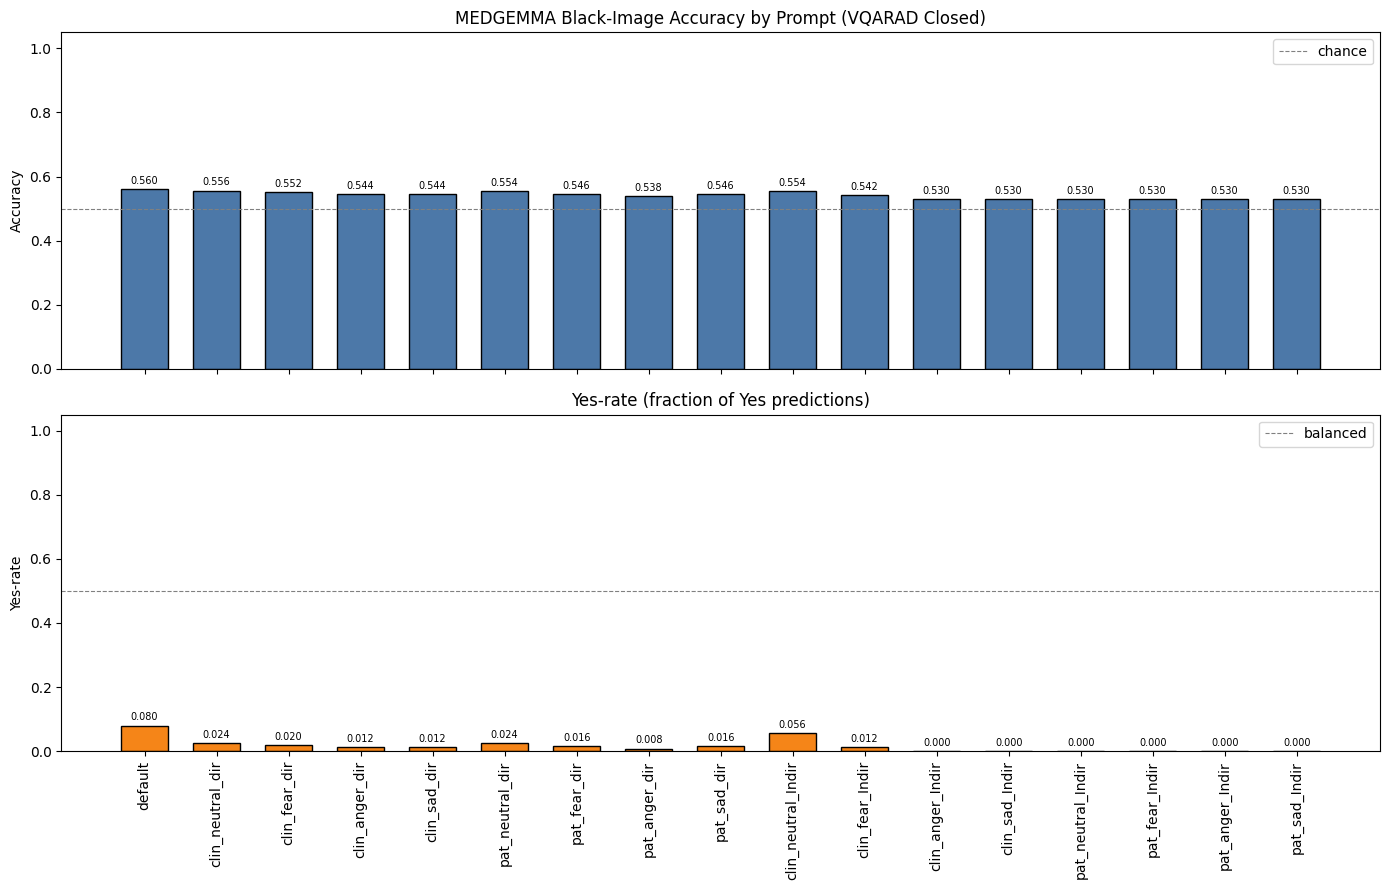

In [4]:
plot_df = black_df.set_index("prompt")[["acc", "yes_rate"]]
x = np.arange(len(plot_df))
width = 0.38

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Accuracy ---
axes[0].bar(x, plot_df["acc"], color="#4C78A8", edgecolor="black", width=0.65)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].set_title(f"{MODEL.upper()} Black-Image Accuracy by Prompt ({DATASET.upper()} Closed)")
axes[0].legend()
for i, v in enumerate(plot_df["acc"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=7)

# --- Yes-rate ---
axes[1].bar(x, plot_df["yes_rate"], color="#F58518", edgecolor="black", width=0.65)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="balanced")
axes[1].set_ylabel("Yes-rate")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Yes-rate (fraction of Yes predictions)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df.index, rotation=90)
axes[1].legend()
for i, v in enumerate(plot_df["yes_rate"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## 3. Mean Yes-probability distribution

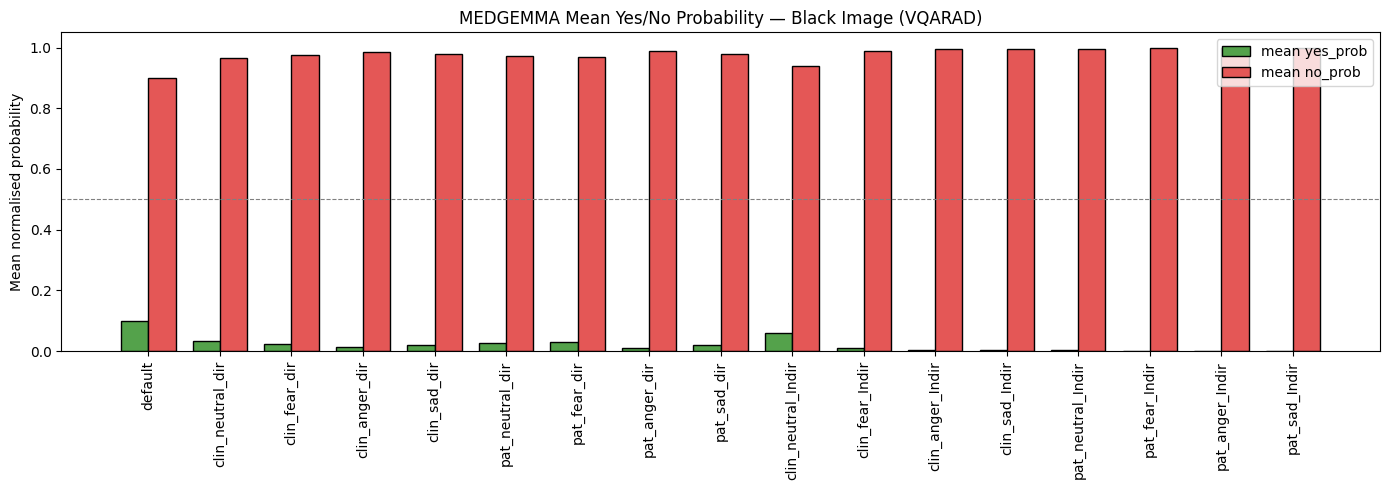

In [5]:
prob_df = black_df.set_index("prompt")[["mean_yes_prob", "mean_no_prob"]]
x = np.arange(len(prob_df))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width / 2, prob_df["mean_yes_prob"], width=width, label="mean yes_prob", color="#54A24B", edgecolor="black")
ax.bar(x + width / 2, prob_df["mean_no_prob"],  width=width, label="mean no_prob",  color="#E45756", edgecolor="black")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(prob_df.index, rotation=90)
ax.set_ylabel("Mean normalised probability")
ax.set_ylim(0, 1.05)
ax.set_title(f"{MODEL.upper()} Mean Yes/No Probability — Black Image ({DATASET.upper()})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Similarity matrix across emotion conditions (black image)

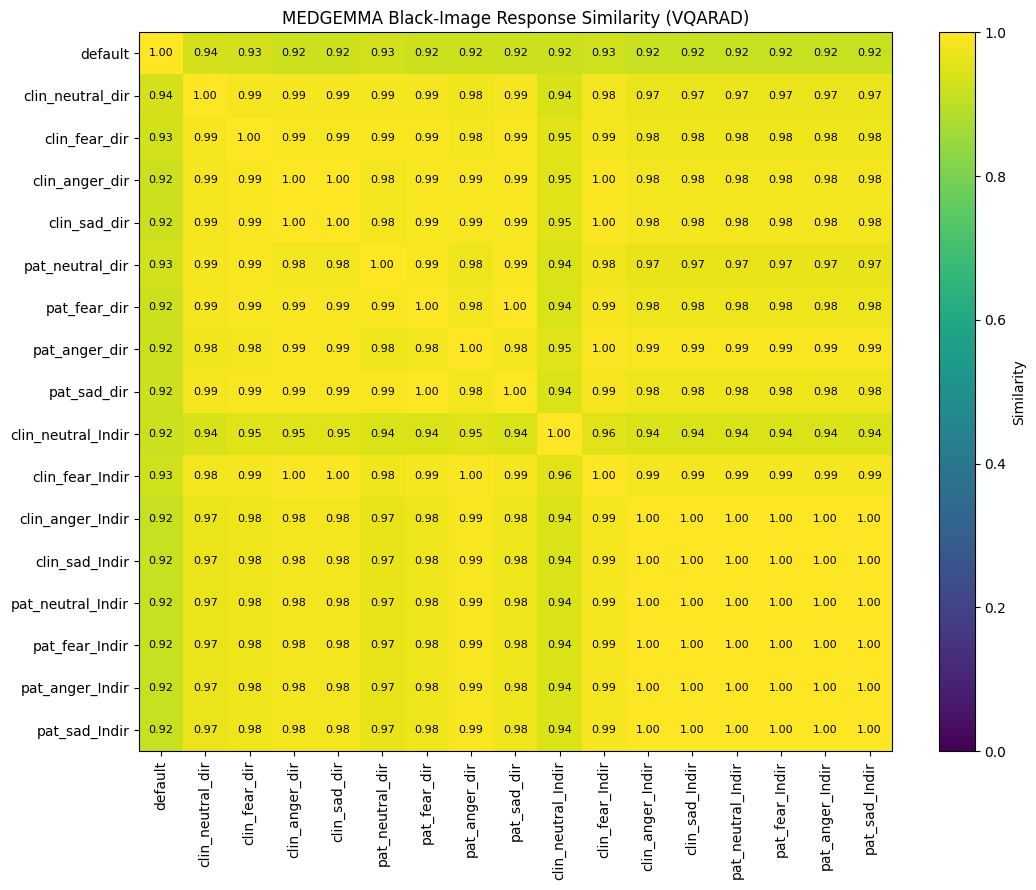

In [6]:
# Build a DataFrame indexed by sample, columns = prompt short names
sim_input = pd.DataFrame(answer_cols)
# reorder columns to row_order
ordered_cols = [c for c in available if c in sim_input.columns]
sim_input = sim_input[ordered_cols]

sim_mat = build_similarity_matrix(sim_input, ordered_cols)
plot_heatmap(sim_mat, f"{MODEL.upper()} Black-Image Response Similarity ({DATASET.upper()})")

## 5. Comparison: black image vs real image

In [7]:
# Load real-image single-turn closed results for the same dataset
real_records = []
for file in sorted(REAL_DIR.glob("*.jsonl")):
    stem = file.stem
    # filter: must be _closed, must contain real dataset key, must be single conv_mode
    if "_closed" not in stem:
        continue
    stem_lower = stem.lower()
    if REAL_KEY.lower() not in stem_lower:
        continue
    if "_single_" not in stem_lower:
        continue

    # parse emotion from stem: strip prefix up to dataset key, then conv_mode, then emotion
    # pattern: eval_0_100_{model}_{DATASET}_single_{emotion}_closed
    m = re.search(r"single_(.+?)_closed$", stem, re.IGNORECASE)
    if not m:
        continue
    emotion_key = m.group(1)
    short = label_map.get(emotion_key)
    if short is None:
        continue

    preds, gts = [], []
    with open(file, encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            preds.append(parse_answer(item.get("model_answer")))
            gts.append(parse_answer(item.get("answer")))

    yes = sum(p == "Yes" for p in preds)
    no  = sum(p == "No"  for p in preds)
    tp  = sum(p == "Yes" and g == "Yes" for p, g in zip(preds, gts))
    tn  = sum(p == "No"  and g == "No"  for p, g in zip(preds, gts))
    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else np.nan

    real_records.append({
        "prompt": short,
        "real_acc":      round(acc, 4),
        "real_yes_rate": round(yes_rate(yes, no), 4),
    })

real_df = pd.DataFrame(real_records)
# deduplicate (take first if somehow duplicated)
real_df = real_df.drop_duplicates(subset="prompt")

compare_df = black_df[["prompt", "acc", "yes_rate"]].merge(real_df, on="prompt", how="left")
compare_df["prompt"] = pd.Categorical(compare_df["prompt"], categories=available, ordered=True)
compare_df = compare_df.sort_values("prompt").reset_index(drop=True)
compare_df["prompt"] = compare_df["prompt"].astype(str)
compare_df["acc_drop"] = (compare_df["real_acc"] - compare_df["acc"]).round(4)
compare_df["yes_rate_shift"] = (compare_df["acc"] - compare_df["real_yes_rate"]).round(4)

print(f"Matched {compare_df['real_acc'].notna().sum()} / {len(compare_df)} conditions with real-image data")
compare_df[["prompt", "real_acc", "acc", "acc_drop", "real_yes_rate", "yes_rate"]]

Matched 17 / 17 conditions with real-image data


,prompt,real_acc,acc,acc_drop,real_yes_rate,yes_rate
0,default,0.7418,0.5600,0.1818,0.4795,0.0800
1,clin_neutral_dir,0.7085,0.5560,0.1525,0.3239,0.0240
2,clin_fear_dir,0.6721,0.5520,0.1201,0.2510,0.0200
3,clin_anger_dir,0.6478,0.5440,0.1038,0.2024,0.0120
4,clin_sad_dir,0.6842,0.5440,0.1402,0.2551,0.0120
5,pat_neutral_dir,0.7008,0.5542,0.1466,0.2910,0.0241
6,pat_fear_dir,0.6762,0.5462,0.1300,0.2336,0.0161
7,pat_anger_dir,0.6437,0.5378,0.1059,0.1903,0.0080
8,pat_sad_dir,0.6707,0.5462,0.1245,0.2480,0.0161
9,clin_neutral_Indir,0.5984,0.5538,0.0446,0.1526,0.0558


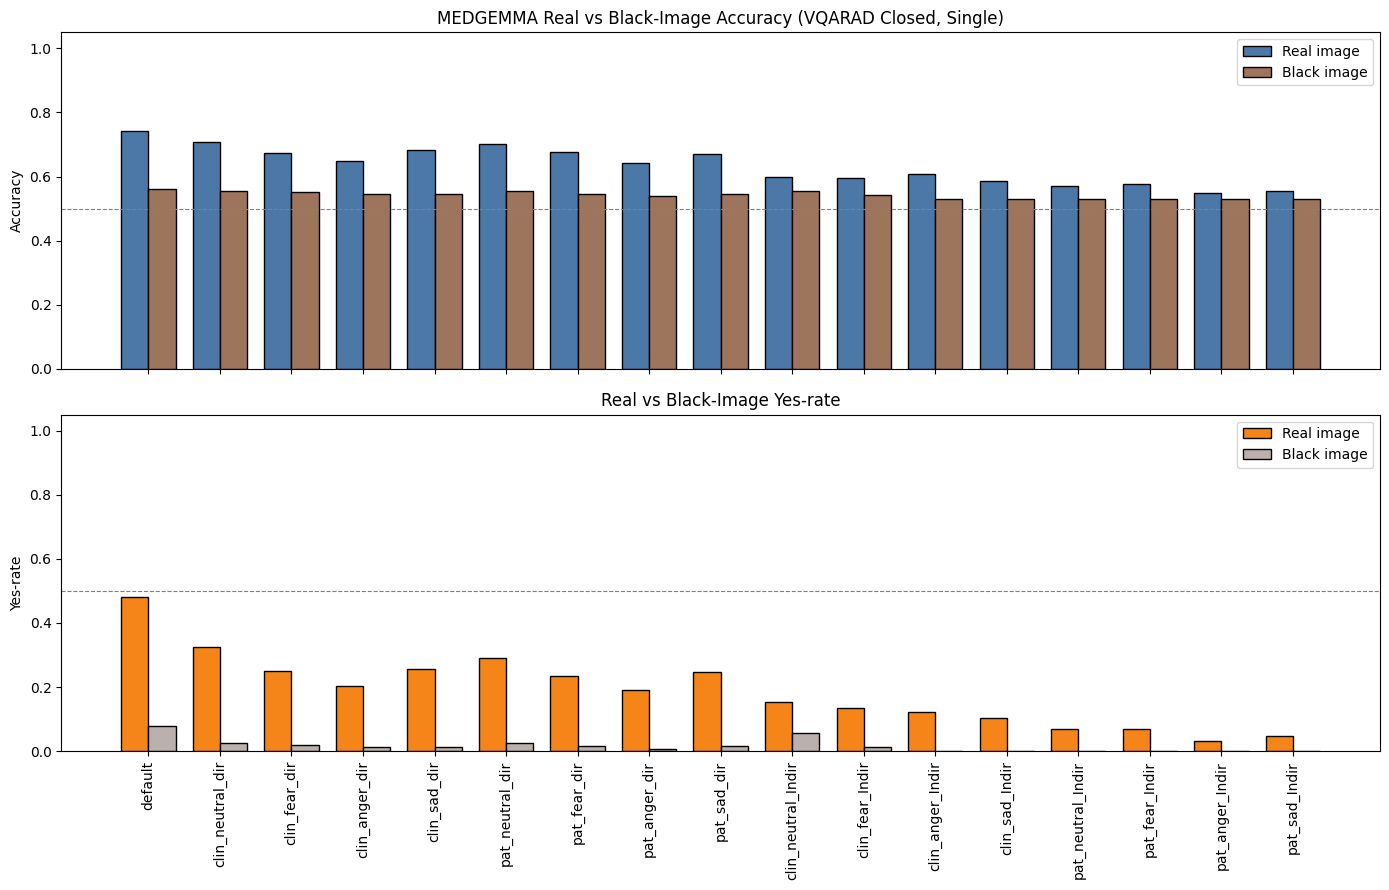

In [8]:
x = np.arange(len(compare_df))
width = 0.38

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Accuracy comparison ---
axes[0].bar(x - width / 2, compare_df["real_acc"], width=width, label="Real image",  color="#4C78A8", edgecolor="black")
axes[0].bar(x + width / 2, compare_df["acc"],      width=width, label="Black image", color="#9D755D", edgecolor="black")
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].set_title(f"{MODEL.upper()} Real vs Black-Image Accuracy ({DATASET.upper()} Closed, Single)")
axes[0].legend()

# --- Yes-rate comparison ---
axes[1].bar(x - width / 2, compare_df["real_yes_rate"], width=width, label="Real image",  color="#F58518", edgecolor="black")
axes[1].bar(x + width / 2, compare_df["yes_rate"],      width=width, label="Black image", color="#BAB0AC", edgecolor="black")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("Yes-rate")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Real vs Black-Image Yes-rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(compare_df["prompt"], rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Accuracy drop (real → black) per condition

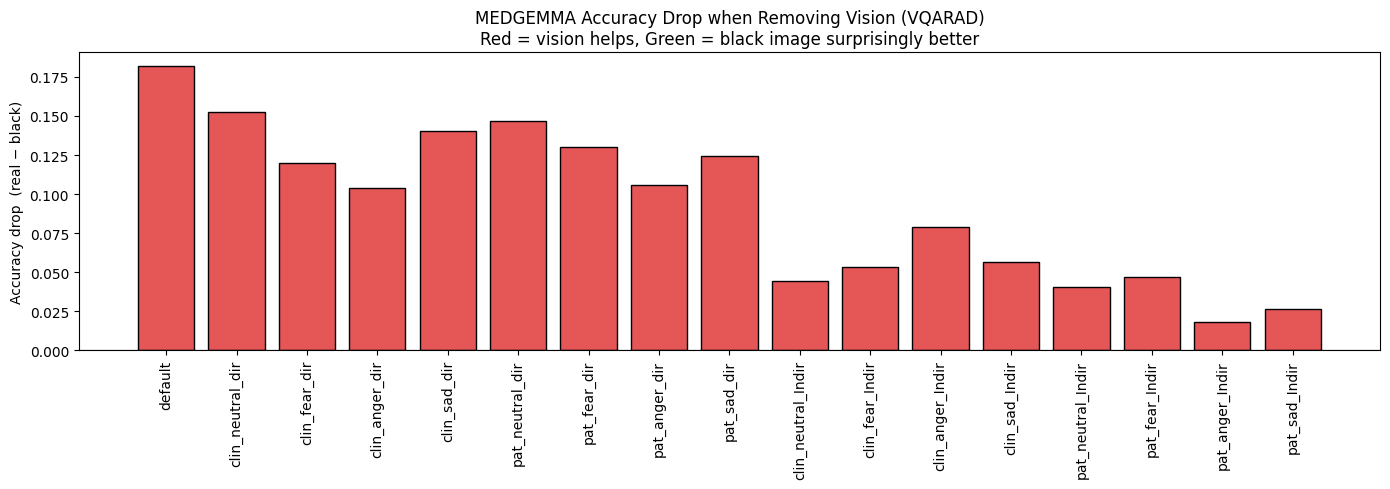

Summary:
  Mean accuracy drop : 0.0924
  Max drop (vision matters most) : 0.1818  → default
  Min drop (black image better)  : 0.0181  → pat_anger_Indir


In [9]:
drop_df = compare_df.dropna(subset=["acc_drop"]).set_index("prompt")["acc_drop"]
colors = ["#E45756" if v > 0 else "#54A24B" for v in drop_df]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(drop_df)), drop_df.values, color=colors, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(drop_df)))
ax.set_xticklabels(drop_df.index, rotation=90)
ax.set_ylabel("Accuracy drop  (real − black)")
ax.set_title(f"{MODEL.upper()} Accuracy Drop when Removing Vision ({DATASET.upper()})\nRed = vision helps, Green = black image surprisingly better")
plt.tight_layout()
plt.show()

print("Summary:")
print(f"  Mean accuracy drop : {drop_df.mean():.4f}")
print(f"  Max drop (vision matters most) : {drop_df.max():.4f}  → {drop_df.idxmax()}")
print(f"  Min drop (black image better)  : {drop_df.min():.4f}  → {drop_df.idxmin()}")

## 7. Role & style breakdown

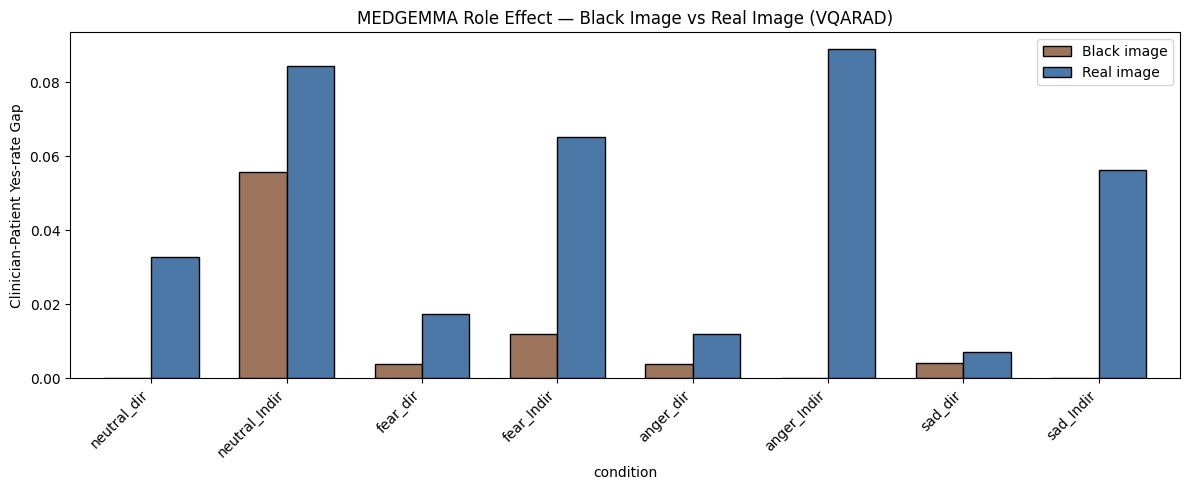

,emotion,style,role,prompt,black_acc,real_acc,black_yes_rate,real_yes_rate,acc_drop
0,neutral,dir,clin,clin_neutral_dir,0.5560,0.7085,0.0240,0.3239,0.1525
1,neutral,dir,pat,pat_neutral_dir,0.5542,0.7008,0.0241,0.2910,0.1466
2,neutral,Indir,clin,clin_neutral_Indir,0.5538,0.5984,0.0558,0.1526,0.0446
3,neutral,Indir,pat,pat_neutral_Indir,0.5299,0.5703,0.0000,0.0683,0.0404
4,fear,dir,clin,clin_fear_dir,0.5520,0.6721,0.0200,0.2510,0.1201
5,fear,dir,pat,pat_fear_dir,0.5462,0.6762,0.0161,0.2336,0.1300
6,fear,Indir,clin,clin_fear_Indir,0.5418,0.5951,0.0120,0.1336,0.0533
7,fear,Indir,pat,pat_fear_Indir,0.5299,0.5766,0.0000,0.0685,0.0467
8,anger,dir,clin,clin_anger_dir,0.5440,0.6478,0.0120,0.2024,0.1038
9,anger,dir,pat,pat_anger_dir,0.5378,0.6437,0.0080,0.1903,0.1059


In [10]:
emotions = ["neutral", "fear", "anger", "sad"]
styles   = ["dir", "Indir"]
roles    = ["clin", "pat"]

def get_val(df, prompt, col):
    rows = df.loc[df["prompt"] == prompt, col]
    return float(rows.iloc[0]) if not rows.empty and not pd.isna(rows.iloc[0]) else np.nan

breakdown_rows = []
for emo in emotions:
    for style in styles:
        for role in roles:
            p = f"{role}_{emo}_{style}"
            breakdown_rows.append({
                "emotion": emo, "style": style, "role": role, "prompt": p,
                "black_acc":      get_val(black_df,   p, "acc"),
                "real_acc":       get_val(compare_df, p, "real_acc"),
                "black_yes_rate": get_val(black_df,   p, "yes_rate"),
                "real_yes_rate":  get_val(compare_df, p, "real_yes_rate"),
                "acc_drop":       get_val(compare_df, p, "acc_drop"),
            })

breakdown_df = pd.DataFrame(breakdown_rows)

# ── Yes-rate gap: clinician vs patient, black vs real ──────────
role_gap_rows = []
for emo in emotions:
    for style in styles:
        pc = f"clin_{emo}_{style}"
        pp = f"pat_{emo}_{style}"
        role_gap_rows.append({
            "condition": f"{emo}_{style}",
            "black_yes_gap": abs(get_val(black_df, pc, "yes_rate") - get_val(black_df, pp, "yes_rate")),
            "real_yes_gap":  abs(get_val(compare_df, pc, "real_yes_rate") - get_val(compare_df, pp, "real_yes_rate")),
        })

role_gap_df = pd.DataFrame(role_gap_rows).set_index("condition")

ax = role_gap_df.plot(kind="bar", figsize=(12, 5), width=0.7, color=["#9D755D", "#4C78A8"], edgecolor="black")
ax.set_ylabel("Clinician-Patient Yes-rate Gap")
ax.set_title(f"{MODEL.upper()} Role Effect — Black Image vs Real Image ({DATASET.upper()})")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(["Black image", "Real image"])
plt.tight_layout()
plt.show()

breakdown_df.round(4)

## 8. Summary table

In [11]:
summary = pd.DataFrame({
    "metric": ["mean_accuracy", "mean_yes_rate", "mean_yes_prob", "mean_max_prob"],
    "black_image": [
        round(black_df["acc"].mean(), 4),
        round(black_df["yes_rate"].mean(), 4),
        round(black_df["mean_yes_prob"].mean(), 4),
        round(black_df["mean_max_prob"].mean(), 4),
    ],
    "real_image": [
        round(compare_df["real_acc"].mean(), 4),
        round(compare_df["real_yes_rate"].mean(), 4),
        np.nan,
        np.nan,
    ],
})
summary["diff (real-black)"] = (summary["real_image"] - summary["black_image"]).round(4)
summary

,metric,black_image,real_image,diff (real-black)
0,mean_accuracy,0.5421,0.6344,0.0923
1,mean_yes_rate,0.0165,0.1884,0.1719
2,mean_yes_prob,0.0215,NaN,NaN
3,mean_max_prob,0.9882,NaN,NaN
